# MSFT vs. caminata aleatoria simulada

Comparamos visualmente el precio de MSFT (datos diarios) con una serie $p$ generada como una caminata aleatoria sin deriva. Para cada una graficamos el nivel y el retorno logarítmico.

### Librerías

In [1]:
library(tidyquant)
library(dplyr)
library(ggplot2)
library(ggpubr)


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 
── Attaching core tidyquant packages ───────────────────────────────────────────────── tidyquant 1.0.12 ──
✔ PerformanceAnalytics 2.1.0      ✔ TTR                  0.24.4
✔ quantmod             0.4.29     ✔ xts                  0.14.2
── Conflicts ──────────────────────────────────────────────────────────────────── tidyquant_conflicts() ──
✖ zoo::as.Date()                 masks base::as.Date()
✖ zoo::as.Date.numeric()         masks base::as.Date.numeric()
✖ PerformanceAnalytics::legend() masks graphics::legend()
✖ quantmod::summary()            masks base::summary()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


Warning messages:
1: package ‘tidyquant’ was built under R version 4.5.3 
2: package ‘xts’ was built under R version 4.5.3 
3: package ‘quantmod’ was built under R version 4.5.3 
4: package ‘TTR’ was built under R version 4.5.3 
5: package ‘PerformanceAnalytics’ was built under R version 4.5.3 



######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.                            #
#                                                                             #
# Use stats::lag() to make sure you're not using dplyr::lag(), or you can add #
# conflictRules('dplyr', exclude = 'lag') to your .Rprofile to stop           #
# dplyr from breaking base R's lag() function.                                #
#                                                                             #
# Code in packages is not affected. It's protected by R's namespace mechanism #
# Set `options(xts.warn_dplyr_breaks_lag = FALSE)` to suppress this warning.  #
#                                      

Warning message:
package ‘dplyr’ was built under R version 4.5.3 
Warning message:
package ‘ggpubr’ was built under R version 4.5.3 


### MSFT, datos diarios

Cargamos el precio de cierre diario de MSFT desde Yahoo Finance y calculamos el retorno logarítmico $r_t=\ln(P_t)-\ln(P_{t-1})$

In [2]:
msft <- tq_get("MSFT", get = "stock.prices", from = "2015-01-01") |>
  select(date, close) |>
  mutate(t = row_number(),
         r = log(close) - log(lag(close)))


### Serie $p$: caminata aleatoria sin deriva

$p_t = p_{t-1} + e_t$, con $e_t \sim N(0,\sigma^2)$ ruido blanco. Usamos el mismo número de observaciones que MSFT y un nivel inicial alto ($p_0=1000$) para que la serie no cruce por cero y el retorno logarítmico quede bien definido en toda la muestra.

In [3]:
set.seed(123)
n     <- nrow(msft)
sigma <- 1
p0    <- 1000

sim_RW <- function(n, sigma = 1, y0 = 0) {
  e <- rnorm(n, mean = 0, sd = sigma)
  y <- numeric(n)
  y[1] <- y0 + e[1]
  for (tt in 2:n) y[tt] <- y[tt - 1] + e[tt]
  y
}

serie_p <- tibble(t = 1:n, p = sim_RW(n, sigma, y0 = p0)) |>
  mutate(rp = log(p) - log(lag(p)))


### Plot de 4 paneles

Fila 1: MSFT (niveles | retorno logarítmico). Fila 2: $p$ simulada (niveles | retorno logarítmico). Sin título, sin etiquetas de ejes ni fechas — el eje horizontal es solo el índice temporal.

Warning messages:
1: Removed 1 row containing missing values or values outside the scale range (`geom_line()`). 
2: Removed 1 row containing missing values or values outside the scale range (`geom_line()`). 


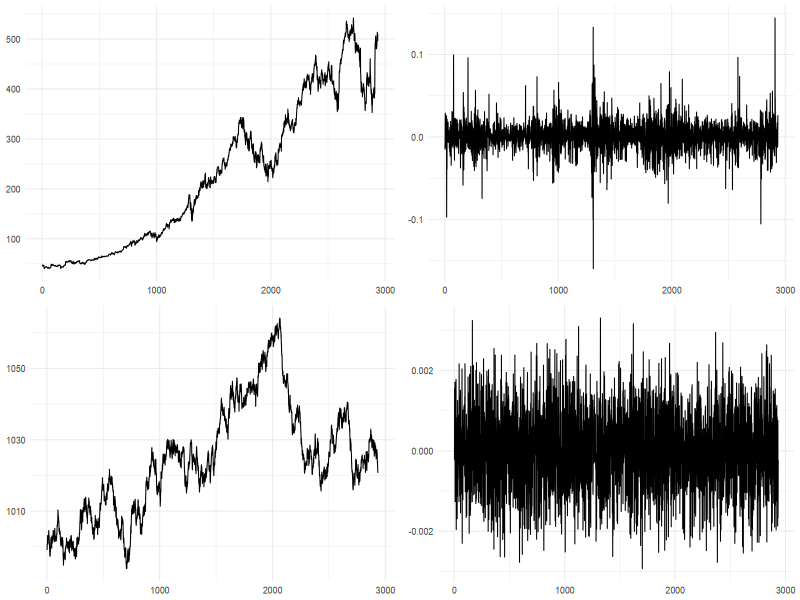

In [4]:
blank_theme <- theme_minimal() +
  theme(axis.title      = element_blank(),
        plot.title      = element_blank(),
        legend.position = "none")

p_msft_level <- ggplot(msft,    aes(x = t, y = close)) + geom_line() + blank_theme
p_msft_ret   <- ggplot(msft,    aes(x = t, y = r))     + geom_line() + blank_theme
p_rw_level   <- ggplot(serie_p, aes(x = t, y = p))     + geom_line() + blank_theme
p_rw_ret     <- ggplot(serie_p, aes(x = t, y = rp))    + geom_line() + blank_theme

ggarrange(p_msft_level, p_msft_ret,
          p_rw_level,   p_rw_ret,
          ncol = 2, nrow = 2)
